In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image

# For training improvements
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # Control training
from tensorflow.keras.layers import BatchNormalization                # Normalize activations

In [2]:
# Path to dataset directory (should contain subfolders like 'with_mask', 'without_mask')
train_dir = 'data'

In [3]:
# ImageDataGenerator helps in Utility to load, preprocess, Normalizing images, Augmenting data (rotation, zoom, flip)
train_gen = ImageDataGenerator(
    rescale = 1./255,           # Normalize pixel values (0–255 → 0–1)
    validation_split = 0.2,     # Split dataset into 80% train / 20% validation
    rotation_range = 20,        # Randomly rotates images up to ±20° to improve generalization.
    zoom_range = 0.2,           # Random zoom to make model robust to scale changes
    horizontal_flip = True      # Flip images horizontally to increase dataset diversity.
)


# Go to my dataset folder, load images in batches, apply preprocessing & augmentation, and assign labels automatically
train_data = train_gen.flow_from_directory(
    train_dir,
    # Model cannot handle different sizes so we can Resize all images to 128x128 fixed size which can give more detail and speed
    target_size = (128, 128),   # Resize images to 128x128 pixels
    batch_size = 32,            # Loads 32 images at a time
    class_mode = 'binary',      # Binary classification (mask / no mask)
    subset = 'training'         # Use training split
)


# Load validation data
val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(128, 128),   # Same size as training data
    batch_size=32,
    class_mode='binary',
    subset='validation'       # Use validation split
)

Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.


In [4]:
# Display class label mapping (e.g., {'with_mask': 0, 'without_mask': 1})
print("Class Labels:", train_data.class_indices)

Class Labels: {'with_mask': 0, 'without_mask': 1}


In [5]:
# 1. Feature Extraction → (Conv + BN + Pool)
# 2. Feature Conversion → (Flatten)
# 3. Decision Making → (Dense + Dropout + Output)

model = Sequential([

    # First Convolution Block
    # (3,3) → Filter Size (Kernel Size) ,Each filter is 3×3, It looks at a small patch of the image at a time, captures local features like edges, corners, textures.
    # input_shape = (128,128,3) -> 128x128 pixels, 3 channels (RGB)
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),  # Extract low-level features
    BatchNormalization(),   # Normalize outputs → stabilizes training

    # Reduce spatial size (downsampling)
    # reduce size + keep important features
    MaxPooling2D(2,2),      

    # Second Convolution Block
    Conv2D(64, (3,3), activation='relu'),  # Learn more complex features
    BatchNormalization(),   # Normalize again
    MaxPooling2D(2,2),      # Downsample

    # Third Convolution Block
    Conv2D(128, (3,3), activation='relu'), # High-level feature extraction
    BatchNormalization(),   # Normalize
    MaxPooling2D(2,2),      # Downsample

    # CNN = Detect edges, shapes
    # Flatten = Convert findings into list
    # Dense = Decide final answer
    # Flatten feature maps into 1D vector
    Flatten(),

    # Fully connected layer
    Dense(128, activation='relu'),  # Learn patterns from extracted features
    # Not using dropout after every layer because in CNN it can disturb to feature learning means it can remove information i.e spatial features
    # Here we used Batch normalization to stabilize training, can prevent from overfitting, adds slight regularization.
    # after dense used dropout because dense layer do decision making so not sensitive to spacial structure
    # Prevent overfitting by randomly dropping neurons
    Dropout(0.5),                   

    # Output layer (binary classification)
    Dense(1, activation='sigmoid')  # Output probability (0 to 1) it will give 0    or 1 (mask or no mask)
])

In [6]:
# Compile model (configure training)
model.compile(
    optimizer = Adam( learning_rate=0.001 ),  # Optimizer with learning rate
    loss='binary_crossentropy',               # Loss for binary classification
    metrics=['accuracy']                      # Track accuracy
)

In [7]:
# EarlyStopping stops training if validation loss doesn't improve
early_stop = EarlyStopping(
    monitor = 'val_loss',           # Watch validation loss
    patience = 3,                   # Wait 3 epochs before stopping
    restore_best_weights = True     # Restore best model weights
)

# ModelCheckpoint saves the best model during training
checkpoint = ModelCheckpoint(
    "best_model.keras",             # File name
    monitor = 'val_accuracy',       # Watch validation accuracy
    save_best_only = True           # Save only best version
)

In [8]:
# Train the model
history = model.fit(
    train_data,                          # Training data generator
    epochs = 5,                           # Number of training cycles
    validation_data = val_data,            # Validation data

    steps_per_epoch = len(train_data),     # Number of batches per epoch
    validation_steps = len(val_data),      # Validation batches

    callbacks = [early_stop, checkpoint]   # Callbacks are tools that monitor training and take action automatically.
)

Epoch 1/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.8297 - loss: 0.6737 - val_accuracy: 0.7139 - val_loss: 1.2945
Epoch 2/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - accuracy: 0.8668 - loss: 0.3655 - val_accuracy: 0.6199 - val_loss: 1.6355
Epoch 3/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 128s 673ms/step - accuracy: 0.9004 - loss: 0.2550 - val_accuracy: 0.8219 - val_loss: 0.5124
Epoch 4/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 101s 537ms/step - accuracy: 0.9087 - loss: 0.2391 - val_accuracy: 0.9417 - val_loss: 0.1559
Epoch 5/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 157s 833ms/step - accuracy: 0.9106 - loss: 0.2206 - val_accuracy: 0.9179 - val_loss: 0.2230


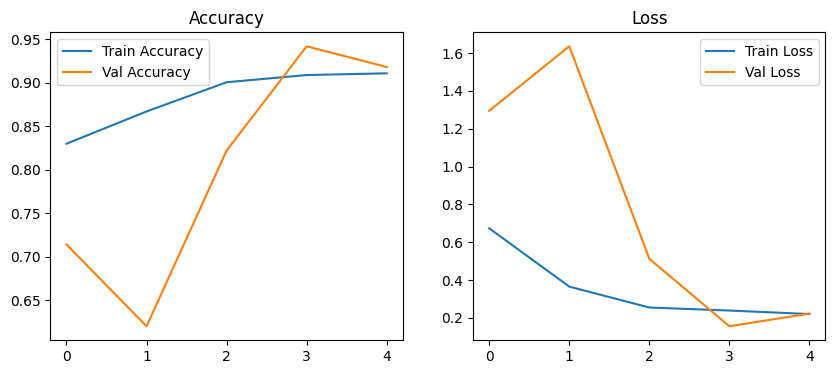

In [9]:
# Plot training results (accuracy & loss)

plt.figure(figsize=(10,4))

# Plot accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')       # Training accuracy
plt.plot(history.history['val_accuracy'], label='Val Accuracy')     # Validation accuracy
plt.title("Accuracy")
plt.legend()

# Plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')               # Training loss
plt.plot(history.history['val_loss'], label='Val Loss')             # Validation loss
plt.title("Loss")
plt.legend()

plt.show()

In [10]:
img_path = 'Image2.jpg'  # Path to test image

# Load and resize image
img = image.load_img(img_path, target_size=(128, 128))

# Convert image to array and normalize
img_array = image.img_to_array(img) / 255.0

# Add batch dimension (model expects shape: (1, 128, 128, 3))
# (1, 128, 128, 3)
#  ↑   ↑    ↑    ↑
#  |   |    |    |
#  |   |    |    └── Channels (RGB)
#  |   |    └────── Width
#  |   └────────── Height
#  └────────────── Batch size
img_array = np.expand_dims(img_array, axis=0)

# Predict probability
prediction = model.predict(img_array)

print("Raw Prediction:", prediction)

# Convert probability to class label
if prediction[0][0] > 0.5:
    print("Prediction: WITHOUT Mask ❌😷")
else:
    print("Prediction: WITH Mask ✅😷")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
Raw Prediction: [[0.00119142]]
Prediction: WITH Mask ✅😷


In [11]:
# Save trained model to file
model.save("mask_final.keras")

print("Model saved successfully!")

Model saved successfully!
